In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    kendalltau,
    theilslopes
)

from IPython.display import display


# Keep notebook output clean.
warnings.filterwarnings("ignore")


# Make DataFrames easier to inspect.
pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

pd.set_option(
    "display.width",
    140
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)


print("=" * 80)
print("H5 ANALYSIS ENVIRONMENT READY")
print("=" * 80)

print("✓ Libraries imported")
print("✓ Statistical functions loaded")
print("✓ Display settings configured")

H5 ANALYSIS ENVIRONMENT READY
✓ Libraries imported
✓ Statistical functions loaded
✓ Display settings configured


In [2]:
# ============================================================
# H5 — ANALYSIS PARAMETERS
# ============================================================

ALPHA = 0.05

CANDIDATE_PATHS = [
    Path(r"C:\Users\bhara\OneDrive\Desktop\DAMO-6994-\DAMO-6994-\DAMO-6994-\data\cleaned dataset\Explanatory_and_Predictive_ED_Analytics_Dataset(2).xlsx"),
    Path(r"C:\Users\bhara\OneDrive\Desktop\DAMO-6994-Capstone-Project-DAMO-6994-\DAMO-6994-\Capstone_Project-DAMO-6994-\data\cleaned dataset\Explanatory_and_Predictive_ED_Analytics_Dataset(2).xlsx"),
    Path(r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\data\cleaned dataset\Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"),
    Path(r"../../data/cleaned dataset/Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"),
    Path(r"data/cleaned dataset/Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx")
]

INPUT_FILE = None
for candidate in CANDIDATE_PATHS:
    if candidate.exists():
        INPUT_FILE = candidate
        break

if INPUT_FILE is None:
    INPUT_FILE = CANDIDATE_PATHS[0]

SHEET_NAME = "Age_Sex"


print(
    f"Significance level: α = {ALPHA}"
)

print(
    f"Source sheet: {SHEET_NAME}"
)

Significance level: α = 0.05
Source sheet: Age_Sex


In [3]:
# ============================================================
# H5 — LOAD AGE_SEX SHEET
# ============================================================

age_sex_df = pd.read_excel(
    INPUT_FILE,
    sheet_name=SHEET_NAME
)


print("=" * 80)
print("H5 — AGE_SEX DATA LOADED")
print("=" * 80)

print(
    f"Rows loaded: {len(age_sex_df):,}"
)

print(
    "\nColumns:"
)

print(
    list(age_sex_df.columns)
)

display(
    age_sex_df.head()
)

H5 — AGE_SEX DATA LOADED
Rows loaded: 190

Columns:
['fiscal_year', 'fiscal_year_start', 'sex', 'age_group', 'population_category', 'ed_visits', 'median_los_minutes', 'median_los_hours']


,fiscal_year,fiscal_year_start,sex,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2003-2004,2003,Female,0–17,Pediatric Population,611154,101,1.6800
1,2003-2004,2003,Female,18–34,Young Adult Population,532768,127,2.1200
2,2003-2004,2003,Female,35–49,Adult Population,503478,129,2.1500
3,2003-2004,2003,Female,50–64,Pre-Senior Population,349504,141,2.3500
4,2003-2004,2003,Female,65–85+,Geriatric Population,478789,203,3.3800


In [4]:
# ============================================================
# H5 — REQUIRED COLUMN VALIDATION
# ============================================================

REQUIRED_COLUMNS = [
    "fiscal_year",
    "fiscal_year_start",
    "sex",
    "age_group",
    "ed_visits",
    "median_los_minutes"
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in age_sex_df.columns
]


if missing_columns:

    raise KeyError(
        "Missing required H5 columns: "
        +
        ", ".join(
            missing_columns
        )
    )


print(
    "✓ All required H5 columns are present."
)

✓ All required H5 columns are present.


In [5]:
# ============================================================
# H5 — DATA CLEANING
# ============================================================

h5_df = (
    age_sex_df[
        REQUIRED_COLUMNS
    ]
    .copy()
)


h5_df["fiscal_year_start"] = pd.to_numeric(
    h5_df["fiscal_year_start"],
    errors="coerce"
)


h5_df["ed_visits"] = pd.to_numeric(
    h5_df["ed_visits"],
    errors="coerce"
)


h5_df["median_los_minutes"] = pd.to_numeric(
    h5_df["median_los_minutes"],
    errors="coerce"
)


h5_df = h5_df.dropna(
    subset=[
        "fiscal_year_start",
        "ed_visits",
        "median_los_minutes"
    ]
).copy()


h5_df = h5_df[
    (h5_df["ed_visits"] >= 0)
    &
    (h5_df["median_los_minutes"] >= 0)
].copy()


h5_df["fiscal_year_start"] = (
    h5_df["fiscal_year_start"]
    .astype(int)
)


print(
    f"Clean H5 records: {len(h5_df):,}"
)

Clean H5 records: 190


In [6]:
# ============================================================
# H5 — FISCAL YEAR VALIDATION
# ============================================================

fiscal_years = (
    sorted(
        h5_df[
            "fiscal_year_start"
        ]
        .unique()
        .tolist()
    )
)


print(
    "Fiscal years:"
)

print(
    fiscal_years
)


if len(fiscal_years) != 19:

    raise ValueError(
        "H5 requires exactly 19 fiscal-year observations, "
        f"but {len(fiscal_years)} fiscal years were found."
    )


expected_years = list(
    range(
        min(fiscal_years),
        max(fiscal_years) + 1
    )
)


if fiscal_years != expected_years:

    raise ValueError(
        "Fiscal years are not a complete consecutive "
        "19-year series."
    )


print(
    "\n✓ Exactly 19 consecutive fiscal years confirmed."
)

Fiscal years:
[2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

✓ Exactly 19 consecutive fiscal years confirmed.


In [7]:
# ============================================================
# H5 — AGE_SEX STRUCTURE VALIDATION
# ============================================================

strata_check = (
    h5_df
    .groupby(
        "fiscal_year_start",
        observed=True
    )
    .agg(
        Sex_Groups=(
            "sex",
            "nunique"
        ),

        Age_Groups=(
            "age_group",
            "nunique"
        ),

        Records=(
            "fiscal_year_start",
            "size"
        )
    )
    .reset_index()
)


display(
    strata_check
)


if not (
    strata_check["Records"] == 10
).all():

    raise ValueError(
        "Every fiscal year is expected to contain "
        "10 Age_Sex aggregate strata."
    )


print(
    "✓ Each fiscal year contains 10 Age_Sex strata."
)

,fiscal_year_start,Sex_Groups,Age_Groups,Records
0,2003,2,5,10
1,2004,2,5,10
2,2005,2,5,10
3,2006,2,5,10
4,2007,2,5,10
5,2008,2,5,10
6,2009,2,5,10
7,2010,2,5,10
8,2011,2,5,10
9,2012,2,5,10


✓ Each fiscal year contains 10 Age_Sex strata.


In [8]:
# ============================================================
# H5 — DUPLICATE CHECK
# ============================================================

duplicate_columns = [
    "fiscal_year_start",
    "sex",
    "age_group"
]


duplicate_mask = (
    h5_df
    .duplicated(
        subset=duplicate_columns,
        keep=False
    )
)


duplicate_count = (
    duplicate_mask.sum()
)


print(
    f"Duplicate fiscal-year × sex × age-group records: "
    f"{duplicate_count:,}"
)


if duplicate_count > 0:

    display(
        h5_df[
            duplicate_mask
        ]
        .sort_values(
            duplicate_columns
        )
    )

    raise ValueError(
        "Duplicate fiscal-year × sex × age-group "
        "records were detected."
    )


print(
    "✓ No duplicate demographic strata found."
)

Duplicate fiscal-year × sex × age-group records: 0
✓ No duplicate demographic strata found.


In [9]:
# ============================================================
# H5 — ESTIMATED RESOURCE BURDEN INDEX
# ============================================================

h5_df["ERBI"] = (
    h5_df["ed_visits"]
    *
    h5_df["median_los_minutes"]
)


print(
    "✓ ERBI calculated."
)


display(
    h5_df[
        [
            "fiscal_year_start",
            "sex",
            "age_group",
            "ed_visits",
            "median_los_minutes",
            "ERBI"
        ]
    ]
    .head()
)

✓ ERBI calculated.


,fiscal_year_start,sex,age_group,ed_visits,median_los_minutes,ERBI
0,2003,Female,0–17,611154,101,61726554
1,2003,Female,18–34,532768,127,67661536
2,2003,Female,35–49,503478,129,64948662
3,2003,Female,50–64,349504,141,49280064
4,2003,Female,65–85+,478789,203,97194167


In [10]:
# ============================================================
# H5 — ANNUAL ERBI SERIES
# ============================================================

annual_erbi = (
    h5_df
    .groupby(
        "fiscal_year_start",
        observed=True
    )
    .agg(
        Annual_ERBI=(
            "ERBI",
            "sum"
        ),

        Annual_ED_Visits=(
            "ed_visits",
            "sum"
        ),

        Mean_Reported_Median_LOS=(
            "median_los_minutes",
            "mean"
        ),

        Median_Reported_Median_LOS=(
            "median_los_minutes",
            "median"
        ),

        Demographic_Strata=(
            "age_group",
            "size"
        )
    )
    .reset_index()
    .sort_values(
        "fiscal_year_start"
    )
    .reset_index(
        drop=True
    )
)


display(
    annual_erbi.round(2)
)

,fiscal_year_start,Annual_ERBI,Annual_ED_Visits,Mean_Reported_Median_LOS,Median_Reported_Median_LOS,Demographic_Strata
0,2003,651859054,4906394,136.7000,128.0000,10
1,2004,724599975,5247805,141.1000,133.0000,10
2,2005,767754955,5417114,144.7000,138.0000,10
3,2006,793522506,5429867,148.6000,142.5000,10
4,2007,864063413,5530328,158.7000,148.0000,10
5,2008,905605092,5559194,165.1000,153.0000,10
6,2009,949223118,5763341,166.9000,154.5000,10
7,2010,1265565448,8171651,157.5000,146.5000,10
8,2011,1426298612,9064585,159.7000,149.5000,10
9,2012,1595626175,10041516,160.5000,150.0000,10


In [11]:
# ============================================================
# H5 — ANNUAL SERIES VALIDATION
# ============================================================

if len(annual_erbi) != 19:

    raise ValueError(
        "Annual ERBI must contain exactly 19 fiscal-year "
        f"observations, but {len(annual_erbi)} were found."
    )


if annual_erbi[
    "Annual_ERBI"
].isna().any():

    raise ValueError(
        "Missing annual ERBI values detected."
    )


if not (
    annual_erbi[
        "Demographic_Strata"
    ] == 10
).all():

    raise ValueError(
        "Every fiscal year must contain exactly "
        "10 Age_Sex strata."
    )


print("=" * 80)
print("H5 ANNUAL SERIES VALIDATED")
print("=" * 80)

print(
    f"Fiscal-year observations: {len(annual_erbi)}"
)

print(
    "✓ No missing annual ERBI values"
)

print(
    "✓ 10 demographic strata per fiscal year"
)

H5 ANNUAL SERIES VALIDATED
Fiscal-year observations: 19
✓ No missing annual ERBI values
✓ 10 demographic strata per fiscal year


In [12]:
# ============================================================
# H5 — MANN-KENDALL MONOTONIC TREND TEST
# ============================================================

years = (
    annual_erbi[
        "fiscal_year_start"
    ]
    .to_numpy()
)


erbi_values = (
    annual_erbi[
        "Annual_ERBI"
    ]
    .to_numpy()
)


kendall_tau, p_value = kendalltau(
    years,
    erbi_values,
    alternative="two-sided"
)


print("=" * 80)
print("H5 — MANN-KENDALL TREND TEST")
print("=" * 80)

print(
    f"Kendall's τ: {kendall_tau:.6f}"
)

print(
    f"P-value: {p_value:.10g}"
)

print(
    f"Alpha: {ALPHA}"
)

H5 — MANN-KENDALL TREND TEST
Kendall's τ: 0.976608
P-value: 3.107400123e-15
Alpha: 0.05


In [13]:
# ============================================================
# H5 — TREND DIRECTION
# ============================================================

if kendall_tau > 0:

    trend_direction = "Positive / Increasing"

elif kendall_tau < 0:

    trend_direction = "Negative / Decreasing"

else:

    trend_direction = "No Monotonic Direction"


print(
    f"Trend direction: {trend_direction}"
)

Trend direction: Positive / Increasing


In [14]:
# ============================================================
# H5 — HYPOTHESIS DECISION
# ============================================================

if p_value < ALPHA:

    decision = "Reject H₀"

    if kendall_tau > 0:

        conclusion = (
            "There is statistically significant evidence "
            "of a positive monotonic trend in the estimated "
            "ED resource-burden proxy across the 19 fiscal years."
        )

    elif kendall_tau < 0:

        conclusion = (
            "There is statistically significant evidence "
            "of a negative monotonic trend in the estimated "
            "ED resource-burden proxy across the 19 fiscal years."
        )

    else:

        conclusion = (
            "The trend test is statistically significant, "
            "but Kendall's tau is approximately zero."
        )

else:

    decision = "Fail to Reject H₀"

    conclusion = (
        "There is insufficient statistical evidence "
        "of a statistically significant monotonic trend "
        "in the estimated ED resource-burden proxy "
        "across the 19 fiscal years."
    )


print(
    f"Decision: {decision}"
)

print(
    f"\nConclusion:\n{conclusion}"
)

Decision: Reject H₀

Conclusion:
There is statistically significant evidence of a positive monotonic trend in the estimated ED resource-burden proxy across the 19 fiscal years.


In [15]:
# ============================================================
# H5 — SEN'S SLOPE
# ============================================================

sen_result = theilslopes(
    erbi_values,
    years,
    alpha=0.95
)


sen_slope = (
    sen_result.slope
)

sen_intercept = (
    sen_result.intercept
)

sen_lower = (
    sen_result.low_slope
)

sen_upper = (
    sen_result.high_slope
)


print("=" * 80)
print("H5 — SEN'S SLOPE")
print("=" * 80)

print(
    f"Sen's slope: {sen_slope:,.4f}"
)

print(
    f"95% lower slope: {sen_lower:,.4f}"
)

print(
    f"95% upper slope: {sen_upper:,.4f}"
)

H5 — SEN'S SLOPE
Sen's slope: 119,140,156.7000
95% lower slope: 103,256,542.7778
95% upper slope: 151,985,468.6667


In [16]:
# ============================================================
# H5 — DESCRIPTIVE LONG-RUN CHANGE
# ============================================================

first_erbi = (
    annual_erbi.iloc[0][
        "Annual_ERBI"
    ]
)

last_erbi = (
    annual_erbi.iloc[-1][
        "Annual_ERBI"
    ]
)


absolute_change = (
    last_erbi
    -
    first_erbi
)


if first_erbi != 0:

    percentage_change = (
        absolute_change
        /
        first_erbi
        *
        100
    )

else:

    percentage_change = np.nan


print(
    f"First fiscal year ERBI: {first_erbi:,.0f}"
)

print(
    f"Last fiscal year ERBI: {last_erbi:,.0f}"
)

print(
    f"Absolute ERBI change: {absolute_change:,.0f}"
)

print(
    f"Percentage ERBI change: {percentage_change:.2f}%"
)

First fiscal year ERBI: 651,859,054
Last fiscal year ERBI: 3,190,225,055
Absolute ERBI change: 2,538,366,001
Percentage ERBI change: 389.40%


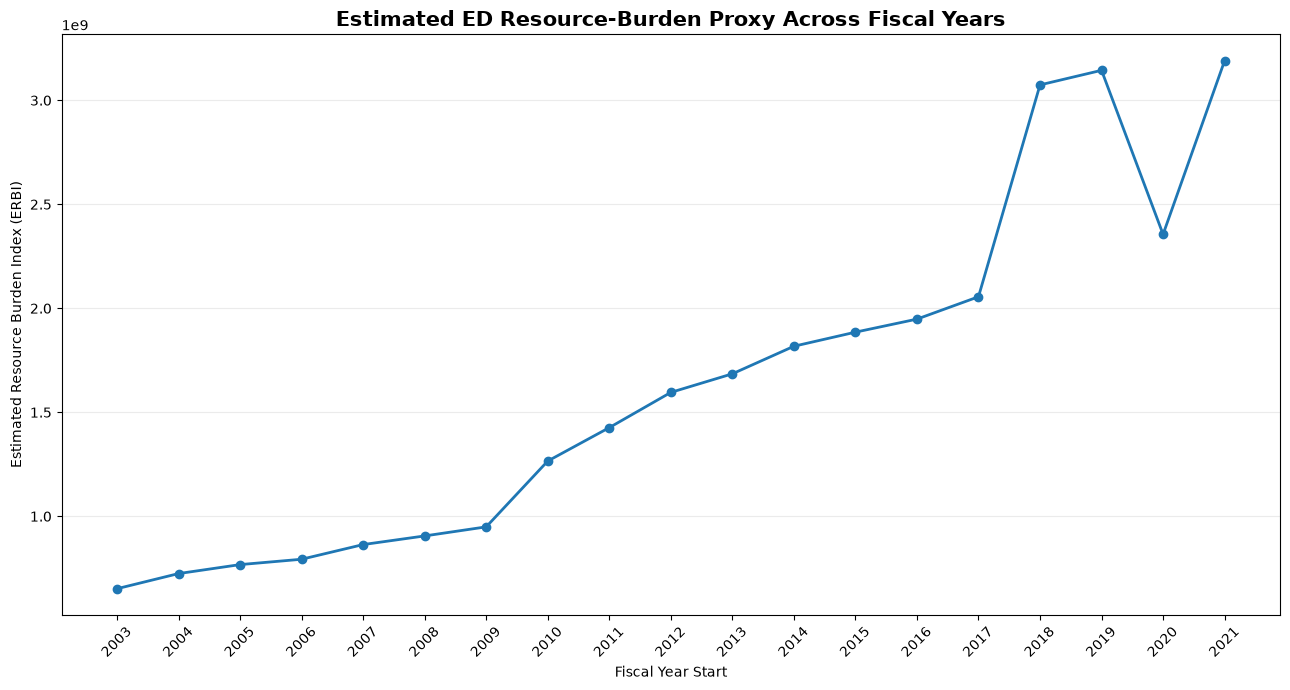

In [17]:
# ============================================================
# H5 VISUAL 1
# ANNUAL ERBI TREND
# ============================================================

plt.figure(
    figsize=(13, 7)
)


plt.plot(
    annual_erbi[
        "fiscal_year_start"
    ],

    annual_erbi[
        "Annual_ERBI"
    ],

    marker="o",

    linewidth=2
)


plt.title(
    "Estimated ED Resource-Burden Proxy Across Fiscal Years",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Fiscal Year Start"
)


plt.ylabel(
    "Estimated Resource Burden Index (ERBI)"
)


plt.xticks(
    years,
    rotation=45
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

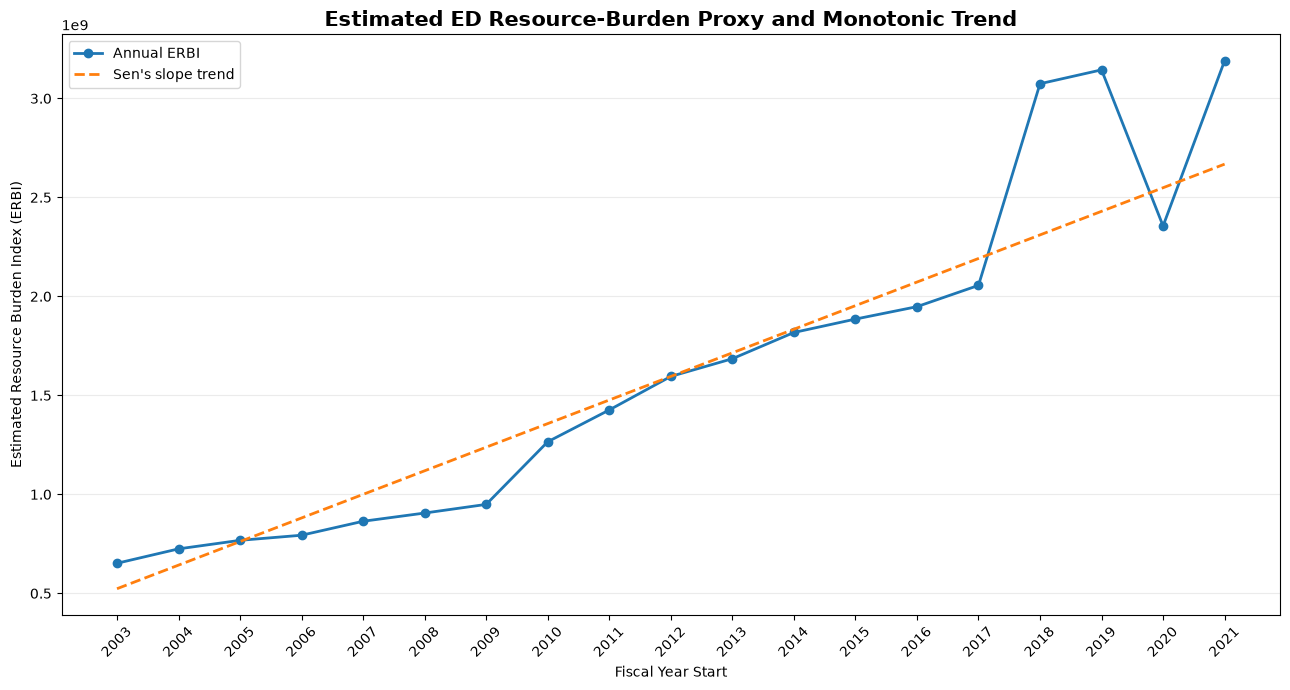

In [18]:
# ============================================================
# H5 VISUAL 2
# ERBI WITH SEN'S SLOPE
# ============================================================

fitted_erbi = (
    sen_intercept
    +
    sen_slope
    *
    years
)


plt.figure(
    figsize=(13, 7)
)


plt.plot(
    years,
    erbi_values,
    marker="o",
    linewidth=2,
    label="Annual ERBI"
)


plt.plot(
    years,
    fitted_erbi,
    linestyle="--",
    linewidth=2,
    label="Sen's slope trend"
)


plt.title(
    "Estimated ED Resource-Burden Proxy and Monotonic Trend",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Fiscal Year Start"
)


plt.ylabel(
    "Estimated Resource Burden Index (ERBI)"
)


plt.xticks(
    years,
    rotation=45
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

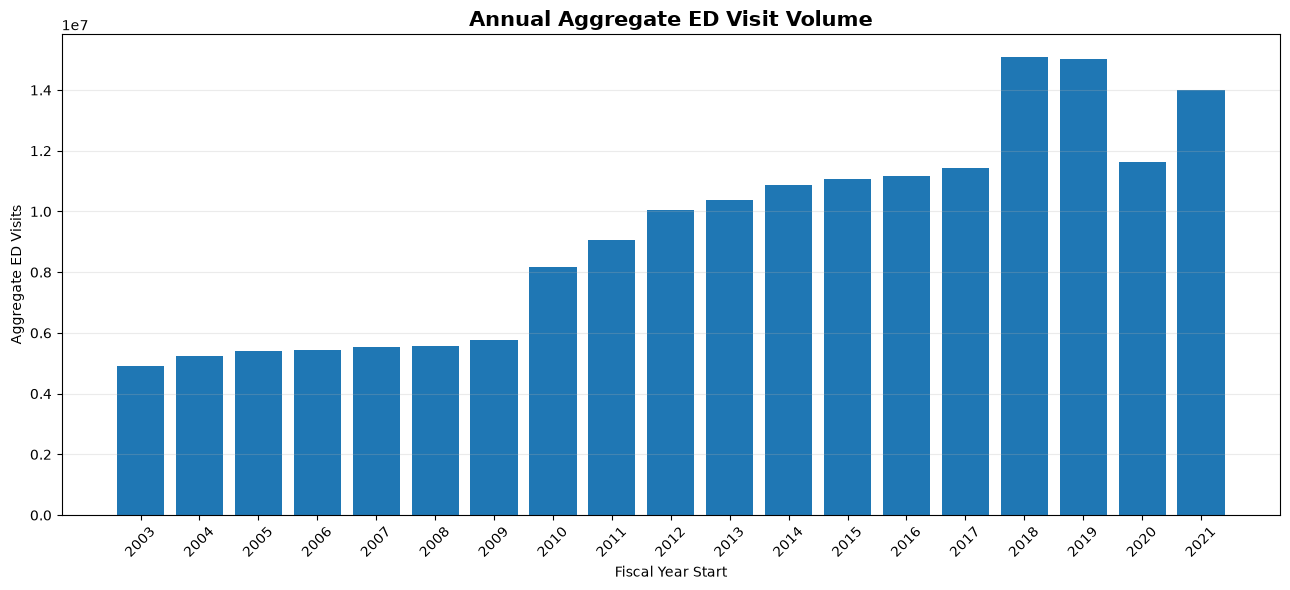

In [19]:
# ============================================================
# H5 VISUAL 3
# ANNUAL ED VISIT VOLUME
# ============================================================

plt.figure(
    figsize=(13, 6)
)


plt.bar(
    annual_erbi[
        "fiscal_year_start"
    ],

    annual_erbi[
        "Annual_ED_Visits"
    ]
)


plt.title(
    "Annual Aggregate ED Visit Volume",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Fiscal Year Start"
)


plt.ylabel(
    "Aggregate ED Visits"
)


plt.xticks(
    years,
    rotation=45
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# H5 — OPTIONAL EXPLORATORY TWO-YEAR FORECAST
# ============================================================

from scipy.stats import linregress


forecast_fit = linregress(
    years,
    erbi_values
)


forecast_slope = (
    forecast_fit.slope
)

forecast_intercept = (
    forecast_fit.intercept
)

forecast_r_squared = (
    forecast_fit.rvalue ** 2
)


future_years = np.array(
    [
        years[-1] + 1,
        years[-1] + 2
    ]
)


forecast_values = (
    forecast_intercept
    +
    forecast_slope
    *
    future_years
)


forecast_table = pd.DataFrame({

    "Fiscal_Year_Start": future_years,

    "Exploratory_ERBI_Forecast": forecast_values

})


display(
    forecast_table.round(2)
)


print(
    f"Linear benchmark R²: "
    f"{forecast_r_squared:.4f}"
)


print(
    "\nForecast interpretation:"
)

print(
    "This is an exploratory benchmark based on only "
    "19 annual observations. It should not be interpreted "
    "as a precise prediction of future ED resource utilization."
)

,Fiscal_Year_Start,Exploratory_ERBI_Forecast
0,2022,"3,049,226,678.7400"
1,2023,"3,190,468,892.0400"


Linear benchmark R²: 0.8958

Forecast interpretation:
This is an exploratory benchmark based on only 19 annual observations. It should not be interpreted as a precise prediction of future ED resource utilization.


In [21]:
# ============================================================
# H5 — FINAL RESULTS TABLE
# ============================================================

h5_results = pd.DataFrame({

    "Hypothesis": [
        "H5"
    ],

    "Research_Question": [
        "Has the estimated ED resource-burden proxy shown a statistically significant monotonic trend across the 19 fiscal years?"
    ],

    "Outcome": [
        "Estimated Resource Burden Index (ERBI)"
    ],

    "Annual_Observations": [
        len(annual_erbi)
    ],

    "Statistical_Test": [
        "Mann-Kendall trend test"
    ],

    "Kendall_Tau": [
        kendall_tau
    ],

    "P_Value": [
        p_value
    ],

    "Alpha": [
        ALPHA
    ],

    "Sen_Slope": [
        sen_slope
    ],

    "Sen_Lower_Slope": [
        sen_lower
    ],

    "Sen_Upper_Slope": [
        sen_upper
    ],

    "Trend_Direction": [
        trend_direction
    ],

    "Decision": [
        decision
    ]
})


display(
    h5_results.round(6)
)

,Hypothesis,Research_Question,Outcome,Annual_Observations,Statistical_Test,Kendall_Tau,P_Value,Alpha,Sen_Slope,Sen_Lower_Slope,Sen_Upper_Slope,Trend_Direction,Decision
0,H5,Has the estimated ED resource-burden proxy sho...,Estimated Resource Burden Index (ERBI),19,Mann-Kendall trend test,0.9766,0.0000,0.0500,"119,140,156.7000","103,256,542.7778","151,985,468.6667",Positive / Increasing,Reject H₀


In [22]:
# ============================================================
# H5 — FINAL INTERPRETATION
# ============================================================

print("=" * 90)
print("H5 — FINAL HYPOTHESIS TEST RESULT")
print("=" * 90)


print(
    "\nResearch Question:"
)

print(
    "Has the estimated ED resource-burden proxy shown "
    "a statistically significant monotonic trend across "
    "the 19 fiscal years?"
)


print(
    "\nStatistical Test:"
)

print(
    "Mann-Kendall trend test"
)


print(
    f"\nKendall's τ = "
    f"{kendall_tau:.6f}"
)


print(
    f"p = "
    f"{p_value:.10g}"
)


print(
    f"α = "
    f"{ALPHA}"
)


print(
    f"Trend direction = "
    f"{trend_direction}"
)


print(
    f"Sen's slope = "
    f"{sen_slope:,.4f} ERBI units per fiscal year"
)


print(
    f"\nDecision: "
    f"{decision}"
)


print(
    f"\nConclusion:\n"
    f"{conclusion}"
)


print(
    "\nMethodological limitation:"
)


print(
    "ERBI is an aggregate resource-burden proxy calculated "
    "as ED visit volume multiplied by reported median LOS. "
    "It is not equivalent to actual total ED minutes. "
    "The 19 annual observations are aggregate fiscal-year "
    "measurements. Therefore, the findings should not be "
    "interpreted as patient-level effects or causal relationships."
)

H5 — FINAL HYPOTHESIS TEST RESULT

Research Question:
Has the estimated ED resource-burden proxy shown a statistically significant monotonic trend across the 19 fiscal years?

Statistical Test:
Mann-Kendall trend test

Kendall's τ = 0.976608
p = 3.107400123e-15
α = 0.05
Trend direction = Positive / Increasing
Sen's slope = 119,140,156.7000 ERBI units per fiscal year

Decision: Reject H₀

Conclusion:
There is statistically significant evidence of a positive monotonic trend in the estimated ED resource-burden proxy across the 19 fiscal years.

Methodological limitation:
ERBI is an aggregate resource-burden proxy calculated as ED visit volume multiplied by reported median LOS. It is not equivalent to actual total ED minutes. The 19 annual observations are aggregate fiscal-year measurements. Therefore, the findings should not be interpreted as patient-level effects or causal relationships.


In [23]:
# ============================================================
# H5 — VARIABLE SAFETY CHECK
# ============================================================

required_h5_variables = [
    "h5_df",
    "annual_erbi",
    "years",
    "erbi_values",
    "kendall_tau",
    "p_value",
    "ALPHA",
    "trend_direction",
    "decision",
    "conclusion",
    "sen_slope",
    "sen_lower",
    "sen_upper",
    "h5_results"
]


missing_variables = [
    variable
    for variable in required_h5_variables
    if variable not in globals()
]


if missing_variables:

    raise NameError(
        "The following required H5 variables are missing: "
        +
        ", ".join(
            missing_variables
        )
    )


print("=" * 80)
print("ALL REQUIRED H5 VARIABLES ARE DEFINED")
print("=" * 80)


for variable in required_h5_variables:

    print(
        f"  ✓ {variable}"
    )

ALL REQUIRED H5 VARIABLES ARE DEFINED
  ✓ h5_df
  ✓ annual_erbi
  ✓ years
  ✓ erbi_values
  ✓ kendall_tau
  ✓ p_value
  ✓ ALPHA
  ✓ trend_direction
  ✓ decision
  ✓ conclusion
  ✓ sen_slope
  ✓ sen_lower
  ✓ sen_upper
  ✓ h5_results
